In [2]:
!pip install ultralytics opencv-python numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.5 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
import cv2
import numpy as np
from google.colab.patches import cv2_imshow


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
from google.colab import files
uploaded = files.upload()

Saving Screenshot 2026-03-12 at 7.55.24 PM.png to Screenshot 2026-03-12 at 7.55.24 PM (1).png


In [5]:
model = YOLO("yolov8n.pt")

#distance estimation function

In [6]:
FOCAL_LENGTH = 800

OBJECT_HEIGHTS = {
    "traffic cone": 0.45,
    "stop sign": 0.75,
    "barrier": 1.0
}

def estimate_distance(label, pixel_height):

    if label not in OBJECT_HEIGHTS:
        return None

    real_height = OBJECT_HEIGHTS[label]

    if pixel_height <= 0:
        return None

    distance = (real_height * FOCAL_LENGTH) / pixel_height
    return round(distance,2)

#run detection + distance estimation


0: 416x640 1 stop sign, 1 bottle, 69.2ms
Speed: 11.6ms preprocess, 69.2ms inference, 34.2ms postprocess per image at shape (1, 3, 416, 640)


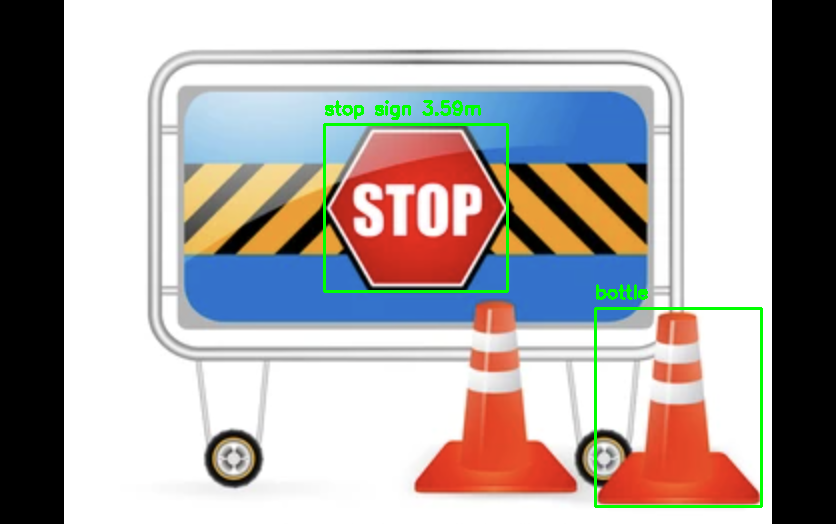

In [7]:
image = cv2.imread("/content/Screenshot 2026-03-12 at 7.55.24 PM.png")

results = model(image)

for r in results:
    for box in r.boxes:

        cls_id = int(box.cls[0])
        label = model.names[cls_id]

        x1,y1,x2,y2 = map(int,box.xyxy[0])

        pixel_height = y2 - y1

        distance = estimate_distance(label,pixel_height)

        if distance:
            text = f"{label} {distance}m"
        else:
            text = label

        cv2.rectangle(image,(x1,y1),(x2,y2),(0,255,0),2)

        cv2.putText(image,text,(x1,y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,(0,255,0),2)

cv2_imshow(image)

#measure FPS

In [8]:
import time

start = time.time()

model(image)

end = time.time()

fps = 1/(end-start)

print("FPS:",fps)


0: 416x640 1 stop sign, 1 bottle, 20.8ms
Speed: 3.7ms preprocess, 20.8ms inference, 3.4ms postprocess per image at shape (1, 3, 416, 640)
FPS: 29.237156519678233


#export optimized model (Edge Device)

In [9]:
model.export(format="onnx", half=True)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 300ms
Prepared 4 packages in 6.76s
Installed 4 packages in 263ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime-gpu==1.24.3
 + onnxslim==0.1.87

requirements: AutoUpdate success ✅ 7.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 22...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:552: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  _export(


ONNX: slimming with onnxslim 0.1.87...
ONNX: converting to FP16...
ONNX: export success ✅ 9.9s, saved as 'yolov8n.onnx' (6.2 MB)

Export complete (10.5s)
Results saved to /content
Predict:         yolo predict task=detect model=yolov8n.onnx imgsz=640 half
Validate:        yolo val task=detect model=yolov8n.onnx imgsz=640 data=coco.yaml half 
Visualize:       https://netron.app


'yolov8n.onnx'

In [10]:
import os

original = os.path.getsize("yolov8n.pt")/1e6
optimized = os.path.getsize("yolov8n.onnx")/1e6

print("Original model size:",round(original,2),"MB")
print("Optimized model size:",round(optimized,2),"MB")

Original model size: 6.55 MB
Optimized model size: 6.46 MB


In [11]:
cv2.imwrite("output_result.jpg", image)

True

In [12]:
from google.colab import files
files.download("output_result.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>